In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
print("Libraries loaded!")

Libraries loaded!


In [5]:
df = pd.read_csv('../data/Telco-Customer-Churn.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
print("=== DATA TYPES ===")
print(df.dtypes)
print("\n=== MISSING VALUES ===")
print(df.isnull().sum())
print("\n=== CHURN DISTRIBUTION ===")
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True).round(3))

=== DATA TYPES ===
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

=== MISSING VALUES ===
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
Pap

In [7]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'], errors='coerce')

In [10]:
print(f"Nulls in TotalCharges after fix: {df['TotalCharges'].isnull().sum()}")
df = df.dropna(subset=['TotalCharges'])
print(f"New shape: {df.shape}")

Nulls in TotalCharges after fix: 11
New shape: (7032, 21)


In [11]:
df['Churn']=df['Churn'].map({'Yes': 1, 'No': 0})
print("Churn value counts:")
print(df['Churn'].value_counts())

Churn value counts:
Churn
0    5163
1    1869
Name: count, dtype: int64


In [12]:
# The logic: customers who churned AND had short tenure


def assign_churn_windows(row):
    if row['Churn'] == 1:
        if row['tenure'] <= 12:
            # High urgency — churning within ~30 days of risk window
            row['churn_30'] = 1
            row['churn_60'] = 1
            row['churn_90'] = 1
        elif row['tenure'] <= 24:
            # Medium urgency
            row['churn_30'] = 0
            row['churn_60'] = 1
            row['churn_90'] = 1
        else:
            # Lower urgency — longer-tenured customer showing risk
            row['churn_30'] = 0
            row['churn_60'] = 0
            row['churn_90'] = 1
    else:
        row['churn_30'] = 0
        row['churn_60'] = 0
        row['churn_90'] = 0
    return row

df = df.apply(assign_churn_windows, axis=1)

print("=== CHURN WINDOW DISTRIBUTION ===")
print(f"churn_30: {df['churn_30'].sum()} customers ({df['churn_30'].mean():.1%})")
print(f"churn_60: {df['churn_60'].sum()} customers ({df['churn_60'].mean():.1%})")
print(f"churn_90: {df['churn_90'].sum()} customers ({df['churn_90'].mean():.1%})")


=== CHURN WINDOW DISTRIBUTION ===
churn_30: 1037 customers (14.7%)
churn_60: 1331 customers (18.9%)
churn_90: 1869 customers (26.6%)


In [13]:
df.to_csv('../data/telco_cleaned.csv', index=False)
print("Saved to data/telco_cleaned.csv")
print(f"Final shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

Saved to data/telco_cleaned.csv
Final shape: (7032, 24)
Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'churn_30', 'churn_60', 'churn_90']


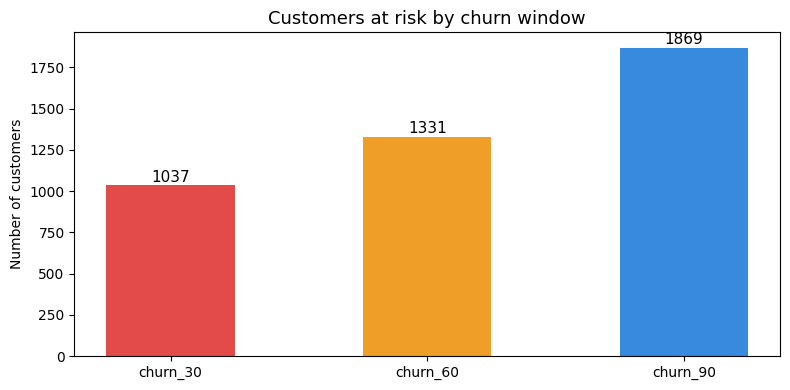

Chart saved!


In [14]:
fig, ax = plt.subplots(figsize=(8, 4))

windows = ['churn_30', 'churn_60', 'churn_90']
counts = [df[w].sum() for w in windows]
colors = ['#E24B4A', '#EF9F27', '#378ADD']

bars = ax.bar(windows, counts, color=colors, width=0.5)
ax.set_title('Customers at risk by churn window', fontsize=13)
ax.set_ylabel('Number of customers')
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            str(count), ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('../data/churn_windows.png', dpi=150)
plt.show()
print("Chart saved!")

SyntaxError: invalid syntax (1307472026.py, line 1)